In [6]:
# %pip install qiskit==1.2.4
# %pip install qiskit-aer==0.15.1
# %pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

# BB84 Protocol with Attacker

## Actors:
- Alice: `Sender of quantum key`
- Bob: `Receiver of quantum key`
- Eve (eavesdropper): `The attacker`

## Sequence of Events:
1. *Alice* generates random quantum `key` and `basis` [<span title="Encodes/Measures purely |0> and |1>">standard (S)</span> or <span title="Encodes/Measures purely |+> and |->">diagonal (D)</span>]
2. *Alice* encodes each qubit with the random basis and sends each qubit to *Bob*
3. *Eve* intercepts every qubit
4. *Eve* guesses the basis used by *Alice* and decodes and encodes the qubit with the guess
5. *Eve* forwards the newly encoded qubit
6. *Bob* receives the tampered qubit
7. *Bob* decodes it with his randomly generated basis
8. *Bob* publicly shares his basis choices
9. *Alice* publicly confirms *Bob's* basis that matches her basis
10. *Alice* and *Bob* discard the bits where their bases did not match, leaving them with the **sifted key**
11. *Alice* and *Bob* publicly compare a **random sample** of their sifted key. They find that despite their bases matching, some of the bits in the sample do not match
12. *Alice* and *Bob* calculate the high error rate, conclude that their communications have been tampered with, and abort the protocol




In [2]:

# 0. QUANTUM RANDOM NUMBER GENERATOR
# Place Qubits into quantum superpositions and measure them to get a random set of Qubits

def qrng(num_bits):
    qc = QuantumCircuit(num_bits, num_bits)
    qc.h(range(num_bits)) # Put all qubits into |+> state
    qc.measure(range(num_bits), range(num_bits))

    backend = BasicSimulator()
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)

    # Little-Endian to Big-Endian (reverse)
    result_str = list(job.result().get_counts().keys())[0][::-1]
    return [int(bit) for bit in result_str]


<IPython.core.display.Javascript object>


               --- RUNNING BB84 PROTOCOL (Attacker Present: True) ---                

+---------------------------------------------------------------+
|                        PROTOCOL LEGEND                        |
+---------------------------------------------------------------+
| S : Standard / Z-basis  (Encodes/Measures purely |0> and |1>) |
| D : Diagonal / X-basis  (Encodes/Measures purely |+> and |->) |
+---------------------------------------------------------------+

--- PHASE 0: ALICE'S PREPARATION ---
-------------------------------------------------------------
|  Qubit  |  Alice Bit  |  Chosen Basis  |  Prepared State  |
-------------------------------------------------------------
|    0    |      0      |       S        |       |0>        |
|    1    |      1      |       D        |       |->        |
|    2    |      1      |       D        |       |->        |
|    3    |      0      |       D        |       |+>        |
|    4    |      1      |       D        |  

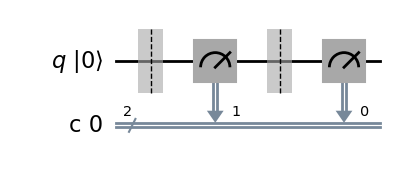


[Qubit 1]
  Alice sends Bit: 1  |  Encodes in: Diagonal (D)
  --> Eve intercepts! Measures in: Standard (S)
  Bob measures in: Diagonal (D)
  Eve's result:    0
  Bob's result:    0


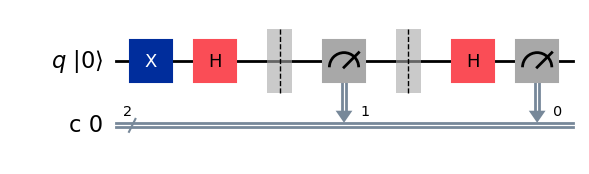


[Qubit 2]
  Alice sends Bit: 1  |  Encodes in: Diagonal (D)
  --> Eve intercepts! Measures in: Diagonal (D)
  Bob measures in: Diagonal (D)
  Eve's result:    1
  Bob's result:    1


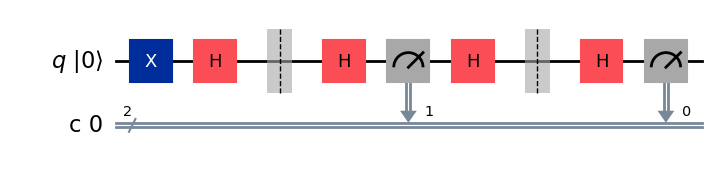


[Qubit 3]
  Alice sends Bit: 0  |  Encodes in: Diagonal (D)
  --> Eve intercepts! Measures in: Standard (S)
  Bob measures in: Diagonal (D)
  Eve's result:    1
  Bob's result:    1


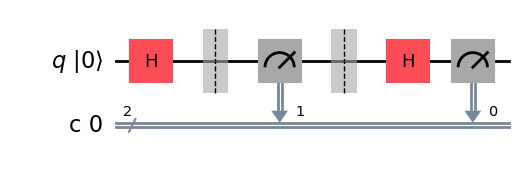


[Qubit 4]
  Alice sends Bit: 1  |  Encodes in: Diagonal (D)
  --> Eve intercepts! Measures in: Standard (S)
  Bob measures in: Diagonal (D)
  Eve's result:    1
  Bob's result:    1


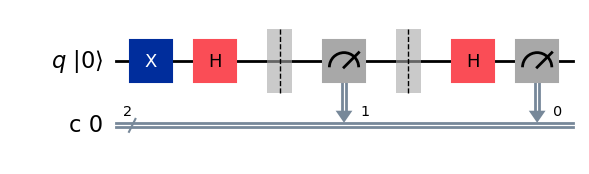


[Qubit 5]
  Alice sends Bit: 0  |  Encodes in: Standard (S)
  --> Eve intercepts! Measures in: Standard (S)
  Bob measures in: Standard (S)
  Eve's result:    0
  Bob's result:    0


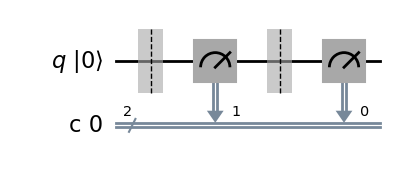


[Qubit 6]
  Alice sends Bit: 0  |  Encodes in: Standard (S)
  --> Eve intercepts! Measures in: Standard (S)
  Bob measures in: Standard (S)
  Eve's result:    0
  Bob's result:    0


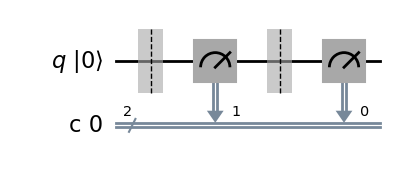


[Qubit 7]
  Alice sends Bit: 0  |  Encodes in: Standard (S)
  --> Eve intercepts! Measures in: Standard (S)
  Bob measures in: Standard (S)
  Eve's result:    0
  Bob's result:    0


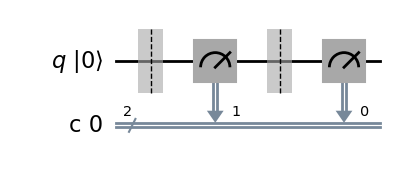


[Qubit 8]
  Alice sends Bit: 0  |  Encodes in: Diagonal (D)
  --> Eve intercepts! Measures in: Diagonal (D)
  Bob measures in: Standard (S)
  Eve's result:    0
  Bob's result:    0


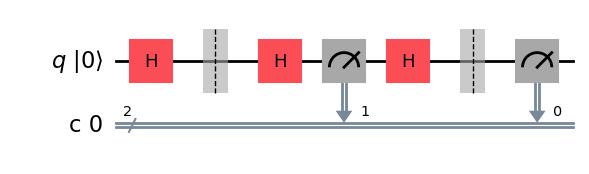


[Qubit 9]
  Alice sends Bit: 1  |  Encodes in: Standard (S)
  --> Eve intercepts! Measures in: Diagonal (D)
  Bob measures in: Standard (S)
  Eve's result:    0
  Bob's result:    1


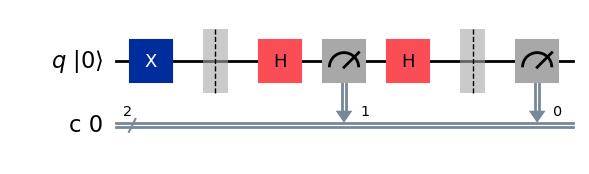


--- PHASE 2 & 3: SIFTING & ERROR CHECKING ---
  Total Qubits:       10
  Sifted Key Length:  9
  Errors Detected:    2
  Error Rate:         22.22%

  >> ALERT: High error rate detected! Eve is listening. ABORT PROTOCOL.

                    --- PHASE 4: COMPLETE TRANSMISSION RECORD ---                    
  [THE 'MATCH?' COLUMN]
  This column ONLY checks if Alice and Bob randomly chose the EXACT SAME BASIS (S or D).
  - YES: The physics align. Bob's reading is mathematically guaranteed to be correct.
  - NO:  The physics mismatch. Bob's reading is a random coin flip (garbage data).
  * EVE TRAP: If Match=YES, Alice and Bob should have identical bits. If they don't,
              it mathematically proves Eve collapsed the photon in the middle!
-------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------
|  Qubit  |  Alice Bit  |  Alice Basis  |  S

In [7]:

from google.colab import output
output.no_vertical_scroll()



# THE FULL BB84 PROTOCOL (WITH ATTACKER)

def run_bb84(num_qubits=10, with_attacker=False):
    print(f"\n{'='*85}")
    title = f"--- RUNNING BB84 PROTOCOL (Attacker Present: {with_attacker}) ---"
    print(f"{title:^85}")
    print(f"{'='*85}")

    basis_name = {0: "Standard (S)", 1: "Diagonal (D)"}
    short_basis = {0: "S", 1: "D"}

    # DYNAMIC LEGEND GENERATOR
    leg_title = "PROTOCOL LEGEND"
    leg_1 = "S : Standard / Z-basis  (Encodes/Measures purely |0> and |1>)"
    leg_2 = "D : Diagonal / X-basis  (Encodes/Measures purely |+> and |->)"
    max_len = max(len(leg_title), len(leg_1), len(leg_2)) + 2
    leg_border = "+" + "-" * max_len + "+"
    print("\n" + leg_border)
    print(f"|{leg_title:^{max_len}}|")
    print(leg_border)
    print(f"| {leg_1:<{max_len-1}}|")
    print(f"| {leg_2:<{max_len-1}}|")
    print(leg_border + "\n")

    # Generate randoms
    alice_bits = qrng(num_qubits)
    alice_bases = qrng(num_qubits)
    bob_bases = qrng(num_qubits)

    # Initialize attacker arrays if needed
    if with_attacker:
        eve_bases = qrng(num_qubits)
        eve_results = []

    bob_results = []
    alice_states = []
    backend = BasicSimulator()


    # PHASE 0: PREPARATION

    print("--- PHASE 0: ALICE'S PREPARATION ---")
    a_bases_str = [short_basis[b] for b in alice_bases]
    for i in range(num_qubits):
        if alice_bases[i] == 0:
            state = "|1>" if alice_bits[i] == 1 else "|0>"
        else:
            state = "|->" if alice_bits[i] == 1 else "|+>"
        alice_states.append(state)

    p0_headers = ["Qubit", "Alice Bit", "Chosen Basis", "Prepared State"]
    p0_widths = [len(h) + 2 for h in p0_headers]
    p0_head_str = "| " + " | ".join([f"{h:^{w}}" for h, w in zip(p0_headers, p0_widths)]) + " |"
    p0_border = "-" * len(p0_head_str)
    print(p0_border)
    print(p0_head_str)
    print(p0_border)
    for i in range(num_qubits):
        print(f"| {i:^{p0_widths[0]}} | {alice_bits[i]:^{p0_widths[1]}} | {a_bases_str[i]:^{p0_widths[2]}} | {alice_states[i]:^{p0_widths[3]}} |")
    print(p0_border + "\n")


    # PHASE 1: TRANSMISSION & MEASUREMENT

    print("--- PHASE 1: TRANSMISSION & MEASUREMENT ---")
    for i in range(num_qubits):
        print(f"\n[Qubit {i}]")

        # Determine circuit size based on Eve's presence
        if with_attacker:
            qc = QuantumCircuit(1, 2) # c-bit 0 for Bob, c-bit 1 for Eve
        else:
            qc = QuantumCircuit(1, 1) # c-bit 0 for Bob only

        # --- ALICE ---
        print(f"  Alice sends Bit: {alice_bits[i]}  |  Encodes in: {basis_name[alice_bases[i]]}")
        if alice_bits[i] == 1:
            qc.x(0)
        if alice_bases[i] == 1:
            qc.h(0)

        qc.barrier() # Alice's Lab Boundary

        # --- EVE ---
        if with_attacker:
            print(f"  --> Eve intercepts! Measures in: {basis_name[eve_bases[i]]}")
            if eve_bases[i] == 1:
                qc.h(0)
            qc.measure(0, 1) # Eve steals the reading into c-bit 1
            if eve_bases[i] == 1: # Eve attempts to hide her tracks
                qc.h(0)
            qc.barrier() # Eve's Lab Boundary

        # --- BOB ---
        print(f"  Bob measures in: {basis_name[bob_bases[i]]}")
        if bob_bases[i] == 1:
            qc.h(0)

        qc.measure(0, 0) # Bob records his reading into c-bit 0

        compiled = transpile(qc, backend)
        job = backend.run(compiled, shots=1)
        result_str = list(job.result().get_counts().keys())[0]

        if with_attacker:
            eve_bit = int(result_str[0])
            bob_bit = int(result_str[1])
            eve_results.append(eve_bit)
            bob_results.append(bob_bit)
            print(f"  Eve's result:    {eve_bit}")
        else:
            bob_bit = int(result_str)
            bob_results.append(bob_bit)

        print(f"  Bob's result:    {bob_bit}")
        display(qc.draw("mpl", initial_state=True))


    # PHASE 2 & 3: SIFTING & ERROR CHECKING

    print("\n" + "="*85)
    print("--- PHASE 2 & 3: SIFTING & ERROR CHECKING ---")

    alice_sifted_key = []
    bob_sifted_key = []

    for i in range(num_qubits):
        if alice_bases[i] == bob_bases[i]:
            alice_sifted_key.append(alice_bits[i])
            bob_sifted_key.append(bob_results[i])

    errors = sum(1 for a, b in zip(alice_sifted_key, bob_sifted_key) if a != b)
    error_rate = errors / len(alice_sifted_key) if len(alice_sifted_key) > 0 else 0
    THRESHOLD = 0.15

    print(f"  Total Qubits:       {num_qubits}")
    print(f"  Sifted Key Length:  {len(alice_sifted_key)}")
    print(f"  Errors Detected:    {errors}")
    print(f"  Error Rate:         {error_rate * 100:.2f}%\n")

    if error_rate > THRESHOLD:
        print("  >> ALERT: High error rate detected! Eve is listening. ABORT PROTOCOL.")
    else:
        print("  >> SUCCESS: Channel is secure. Keys match perfectly.")


    # PHASE 4: FINAL SUMMARY

    print("\n" + "="*85)
    print(f"{'--- PHASE 4: COMPLETE TRANSMISSION RECORD ---':^85}")
    print("="*85)

    # EXPLANATION BLOCK MATCH
    print("  [THE 'MATCH?' COLUMN]")
    print("  This column ONLY checks if Alice and Bob randomly chose the EXACT SAME BASIS (S or D).")
    print("  - YES: The physics align. Bob's reading is mathematically guaranteed to be correct.")
    print("  - NO:  The physics mismatch. Bob's reading is a random coin flip (garbage data).")
    if with_attacker:
        print("  * EVE TRAP: If Match=YES, Alice and Bob should have identical bits. If they don't,")
        print("              it mathematically proves Eve collapsed the photon in the middle!")
    print("-" * 85)

    if with_attacker:
        headers = ["Qubit", "Alice Bit", "Alice Basis", "State", "Eve Basis", "Eve Bit", "Bob Basis", "Bob Bit", "Match?"]
        e_bases_str = [short_basis[b] for b in eve_bases]
    else:
        headers = ["Qubit", "Alice Bit", "Alice Basis", "State", "Bob Basis", "Bob Bit", "Match?"]

    widths = [len(h) + 2 for h in headers]
    header_row = "| " + " | ".join([f"{h:^{w}}" for h, w in zip(headers, widths)]) + " |"
    table_border = "-" * len(header_row)

    print(table_border)
    print(header_row)
    print(table_border)

    b_bases_str = [short_basis[b] for b in bob_bases]

    for i in range(num_qubits):
        match_str = "YES" if alice_bases[i] == bob_bases[i] else "NO"
        a_b = a_bases_str[i]
        b_b = b_bases_str[i]

        if with_attacker:
            e_b = e_bases_str[i]
            row_str = f"| {i:^{widths[0]}} | {alice_bits[i]:^{widths[1]}} | {a_b:^{widths[2]}} | {alice_states[i]:^{widths[3]}} | {e_b:^{widths[4]}} | {eve_results[i]:^{widths[5]}} | {b_b:^{widths[6]}} | {bob_results[i]:^{widths[7]}} | {match_str:^{widths[8]}} |"
        else:
            row_str = f"| {i:^{widths[0]}} | {alice_bits[i]:^{widths[1]}} | {a_b:^{widths[2]}} | {alice_states[i]:^{widths[3]}} | {b_b:^{widths[4]}} | {bob_results[i]:^{widths[5]}} | {match_str:^{widths[6]}} |"

        print(row_str)

    print(table_border)

    print(f"\n  >> Final Alice Sifted Key: {alice_sifted_key}")
    print(f"  >> Final Bob Sifted Key:   {bob_sifted_key}")
    print("="*85 + "\n")

# Run it twice to see the tables adapt perfectly!
# run_bb84(num_qubits=10, with_attacker=False)
run_bb84(num_qubits=10, with_attacker=True)
